## Introduction:

This project analyzes store performance using factors such as store size, product availability, and customer footfall to understand the key drivers of sales and efficiency. The goal is to identify patterns and provide actionable business insights.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("D:\\Data analytics\\mini projects\\sales-analysis-project\\data\\Stores.csv")

#### Exploratory Data Analysis (EDA)

In [5]:
print(df.head())
print(df.tail())
print(df.info())
print(df.describe())
print(df.columns)
print(df.shape)

   Store ID   Store_Area  Items_Available  Daily_Customer_Count  Store_Sales
0          1        1659             1961                   530        66490
1          2        1461             1752                   210        39820
2          3        1340             1609                   720        54010
3          4        1451             1748                   620        53730
4          5        1770             2111                   450        46620
     Store ID   Store_Area  Items_Available  Daily_Customer_Count  Store_Sales
891        892        1582             1910                  1080        66390
892        893        1387             1663                   850        82080
893        894        1200             1436                  1060        76440
894        895        1299             1560                   770        96610
895        896        1174             1429                  1110        54340
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 896 entries, 0

Total rows - 896,
total columns - 5, 
only consists of numerical columns which are : Store ID, Store_Area, Items_Available, Daily_Customer_Count, Store_Sales

"Store_ID" :- unique identifier,
"Store_Area" :- physical measurement,
"Items_Available" :- number of products,
"Daily_Customer_Count" :- daily footfall,
"Store_Sales" :- revenue.

#### Data Cleaning process

i) Missing value check:

In [6]:
df.isnull().sum()   

Store ID                0
Store_Area              0
Items_Available         0
Daily_Customer_Count    0
Store_Sales             0
dtype: int64

There is no missing values in this dataset

ii) Duplicate values check:

In [7]:
int(df.duplicated().sum())

0

There is no duplicate values in this dataset

iii) Data type check:

In [8]:
print(df.dtypes)

Store ID                int64
Store_Area              int64
Items_Available         int64
Daily_Customer_Count    int64
Store_Sales             int64
dtype: object


In this dataset all the columns are of integer type

iv) Checking for spaces in colums name (Formating):

In [9]:

for col in df.columns:
    if col != col.strip():
        print(f"There is a space in {repr(col)}")

There is a space in 'Store ID '


There is a space in the naming of the column named "Store ID". 

In [10]:
df.columns = df.columns.str.strip()

Fixed the column name

iv) Negetive value check:

In [11]:
df.describe()

,Store ID,Store_Area,Items_Available,Daily_Customer_Count,Store_Sales
count,896.000000,896.000000,896.000000,896.000000,896.000000
mean,448.500000,1485.409598,1782.035714,786.350446,59351.305804
std,258.797218,250.237011,299.872053,265.389281,17190.741895
min,1.000000,775.000000,932.000000,10.000000,14920.000000
25%,224.750000,1316.750000,1575.500000,600.000000,46530.000000
50%,448.500000,1477.000000,1773.500000,780.000000,58605.000000
75%,672.250000,1653.500000,1982.750000,970.000000,71872.500000
max,896.000000,2229.000000,2667.000000,1560.000000,116320.000000


There is no negetive values in this dataset

Creating Sales per customer and Sales per Area for each and every store

In [12]:
df["Sales_per_customer"] = df["Store_Sales"]/df["Daily_Customer_Count"]
df["Sales_per_area"] = df["Store_Sales"]/df["Store_Area"]

#### Quesion 1:
What is the average store sales ?

In [13]:
int(df['Store_Sales'].mean())

59351

Answer - The average store sales is 59351.

#### Question 2:
Which store has the maximum and minimum sales ?

In [14]:
print(df.loc[df["Store_Sales"].idxmax(), "Store ID"])
print(df.loc[df["Store_Sales"].idxmin(), "Store ID"])

650
32


Answer - The store having the ID 650 generates the highest revenue and the store having the ID 32 generates the lowest revenue.

#### Question 3:
"Large store means higher revenue" - Is it true ?

In [15]:
df[['Store_Area', 'Store_Sales']].corr()

,Store_Area,Store_Sales
Store_Area,1.000000,0.097474
Store_Sales,0.097474,1.000000


The correlation between Store Area and Store Sales is ~0.09, which indicates a very weak positive relationship (Mathematically).

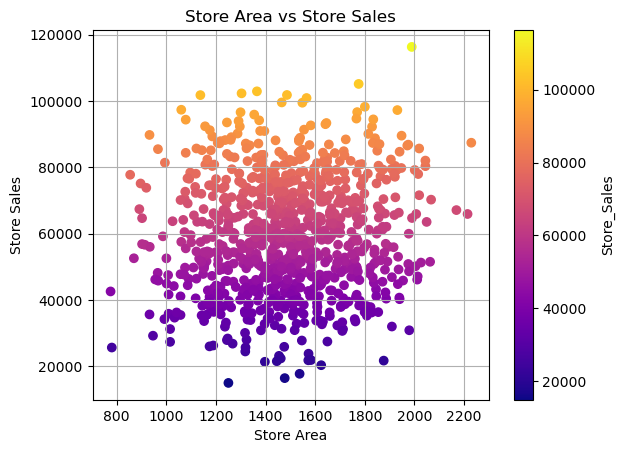

In [16]:
plt.scatter(df["Store_Area"], df["Store_Sales"], c = df["Store_Sales"], cmap='plasma')
plt.colorbar(label = "Store_Sales")
plt.xlabel("Store Area")
plt.ylabel("Store Sales")
plt.title("Store Area vs Store Sales")
plt.grid(True)
plt.show()

In [17]:
df[["Store_Area", "Sales_per_area"]].corr()

,Store_Area,Sales_per_area
Store_Area,1.000000,-0.446563
Sales_per_area,-0.446563,1.000000


The correlation between Store Area and Sales per Area is approximately -0.45, indicating a moderate negative relationship (Mathematically).

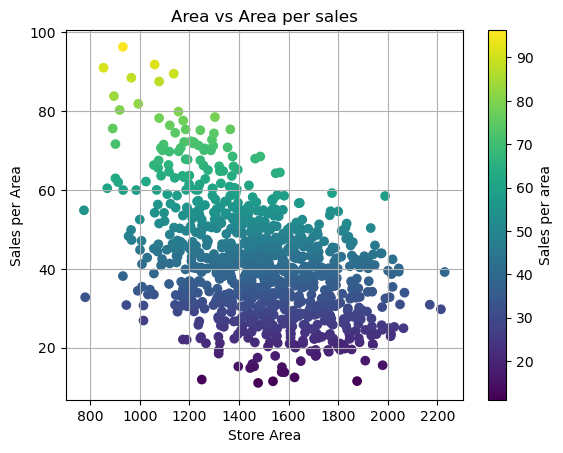

In [18]:
plt.scatter(df["Store_Area"], df["Sales_per_area"], c = df["Sales_per_area"], cmap='viridis')
plt.colorbar(label= "Sales per area")
plt.xlabel("Store Area")
plt.ylabel("Sales per Area")
plt.title("Area vs Area per sales")
plt.grid(True)
plt.show()

There is a weak relationship between store area and sales.

Larger stores do not always generate higher revenue. While they may have higher total sales, their efficiency (sales per area) is often lower compared to smaller stores.

This suggests that store size alone is not the main factor driving revenue.

#### Quesion 4:
"Higher customer count means higher revenue" - is it true ?

In [19]:
df[["Daily_Customer_Count", "Store_Sales"]].corr()

,Daily_Customer_Count,Store_Sales
Daily_Customer_Count,1.000000,0.008629
Store_Sales,0.008629,1.000000


The correlation between Daily count customer and Store Sales is ~0.009, which indicates a very weak positive relationship (Mathematically).

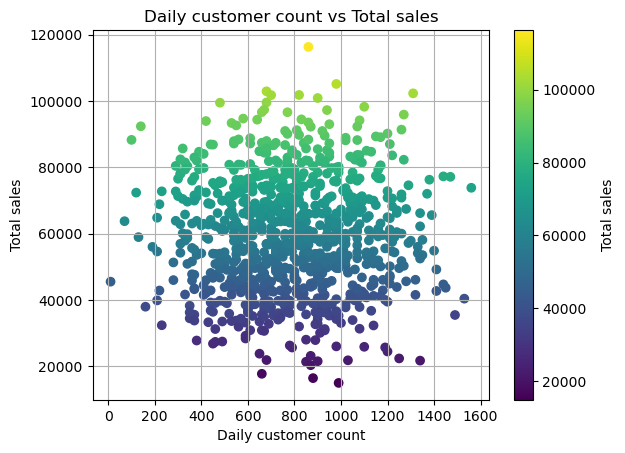

In [20]:
plt.scatter(df["Daily_Customer_Count"], df["Store_Sales"], c = df["Store_Sales"], cmap='viridis')
plt.colorbar(label= "Total sales")
plt.xlabel("Daily customer count")
plt.ylabel("Total sales")
plt.title("Daily customer count vs Total sales")
plt.grid(True)
plt.show()

In [21]:
df[["Daily_Customer_Count", "Sales_per_customer"]].corr()

,Daily_Customer_Count,Sales_per_customer
Daily_Customer_Count,1.000000,-0.338249
Sales_per_customer,-0.338249,1.000000


The correlation between daily customer count and sales per customer is approximately -0.3, indicating a weak negative relationship.

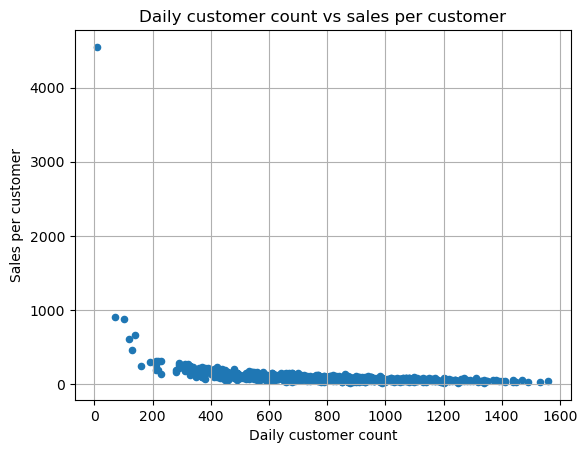

In [22]:
plt.scatter(df["Daily_Customer_Count"], df["Sales_per_customer"], s=20)
plt.xlabel("Daily customer count")
plt.ylabel("Sales per customer")
plt.title("Daily customer count vs sales per customer")
plt.grid(True)
plt.show()

There is a weak relationship between daily customer count and total sales, indicating that more customers do not necessarily lead to higher revenue.

Further analysis using sales per customer suggests that stores with higher footfall often generate lower revenue per customer. This indicates potential inefficiencies in customer conversion.


#### Question 5:
Are the stores with larger size attracting more customers ?


In [23]:
df[["Store_Area", "Daily_Customer_Count"]].corr()

,Store_Area,Daily_Customer_Count
Store_Area,1.000000,-0.041423
Daily_Customer_Count,-0.041423,1.000000


The correlation between Store Area and Daily customer count is -0.04, which indicates a very weak positive relationship (Mathematically).

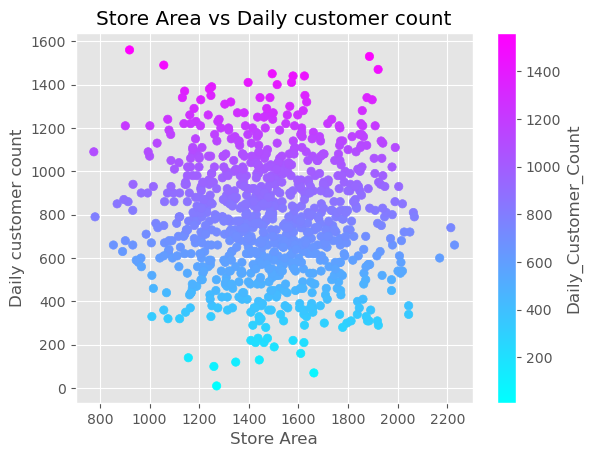

In [24]:
plt.style.use("ggplot")
plt.scatter(df["Store_Area"], df["Daily_Customer_Count"], c = df["Daily_Customer_Count"], cmap='cool')
plt.colorbar(label ="Daily_Customer_Count")
plt.xlabel("Store Area")
plt.ylabel("Daily customer count")
plt.title("Store Area vs Daily customer count")
plt.grid(True)
plt.show()


There is a very weak negative relationship between store area and daily customer count, indicating that larger stores do not necessarily attract more customers.

The scatter plot further confirms the absence of a clear trend, suggesting that store size has little to no impact on customer footfall. Other factors such as location, product variety, or pricing may play a more significant role in attracting customers.

## Key Insights:

- Store size has little impact on customer count and only a weak relationship with sales.
- Higher customer footfall does not guarantee higher revenue.
- Some smaller stores perform more efficiently in terms of sales per area.
- Sales per customer varies significantly, indicating differences in customer spending behavior.

## Recommendations:

- Focus on improving customer conversion rather than only increasing footfall.
- Optimize store layout and product placement to improve sales per area.
- Analyze high-performing small stores to replicate their strategies.
- Investigate stores with high traffic but low sales for potential issues.

## Conclusion:

This analysis highlights that factors beyond store size, such as efficiency and customer behavior, play a crucial role in determining store performance. Businesses should focus on optimizing conversion and operational efficiency rather than relying solely on increasing store size or footfall.